In [19]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set visualization style
sns.set_style("whitegrid")

In [22]:
# Load the Excel dataset

file_path = "/content/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 541909
Number of columns: 8


In [23]:
# Display the first five rows

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


In [24]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [25]:
# Check the shape of the dataset

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 541909
Columns: 8


In [26]:
# Check column names

print("Column names:")
for column in df.columns:
    print("-", column)

Column names:
- InvoiceNo
- StockCode
- Description
- Quantity
- InvoiceDate
- UnitPrice
- CustomerID
- Country


In [27]:
# Generate statistical summary

df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.00,25900.00,573585.00,1114.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.00,NaN,NaN,NaN,9.55,-80995.00,1.00,3.00,10.00,80995.00,218.08
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.00,NaN,NaN,NaN,4.61,-11062.06,1.25,2.08,4.13,38970.00,96.76
CustomerID,406829.00,NaN,NaN,NaN,15287.69,12346.00,13953.00,15152.00,16791.00,18287.00,1713.60
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# Check missing values

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_summary = missing_summary.sort_values(
    by='Missing Values',
    ascending=False
)

missing_summary

,Missing Values,Percentage
CustomerID,135080,24.93
Description,1454,0.27
StockCode,0,0.00
InvoiceNo,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


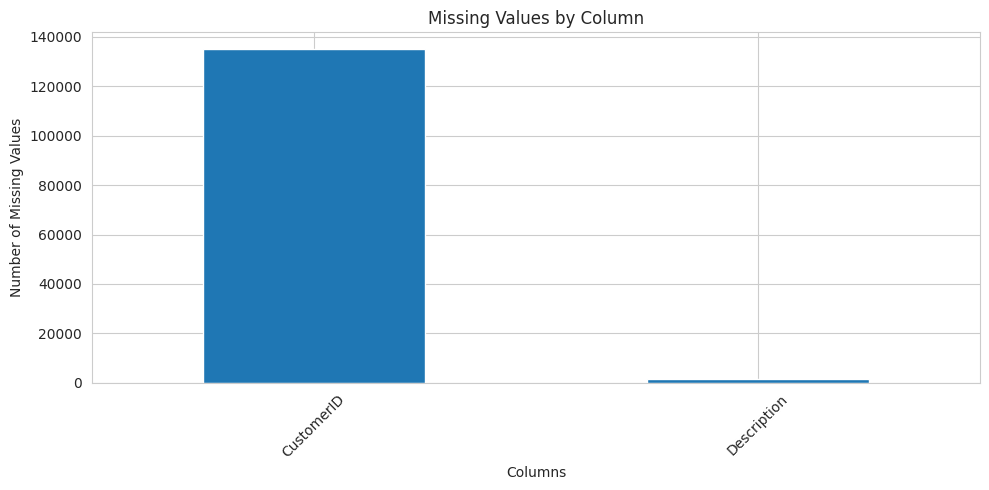

In [30]:
# Visualize missing values

plt.figure(figsize=(10, 5))

missing_values[missing_values > 0].sort_values(
    ascending=False
).plot(kind='bar')

plt.title('Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
# Create a copy of the original dataset for cleaning

cleaned_df = df.copy()

# Remove rows with missing product descriptions

cleaned_df = cleaned_df.dropna(subset=['Description'])

print("Original rows:", len(df))
print("Rows after handling missing descriptions:", len(cleaned_df))

Original rows: 541909
Rows after handling missing descriptions: 540455


In [32]:
# Check remaining missing values

cleaned_df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,133626
Country,0


In [33]:
# Check for duplicate rows

duplicate_count = cleaned_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


In [34]:
# Remove duplicate records

cleaned_df = cleaned_df.drop_duplicates()

print("Rows after removing duplicates:", len(cleaned_df))

Rows after removing duplicates: 535187


In [35]:
# Verify that duplicates have been removed

print("Remaining duplicate rows:", cleaned_df.duplicated().sum())

Remaining duplicate rows: 0


In [36]:
# Check quantity and unit price

print("Minimum Quantity:", cleaned_df['Quantity'].min())
print("Maximum Quantity:", cleaned_df['Quantity'].max())

print("Minimum Unit Price:", cleaned_df['UnitPrice'].min())
print("Maximum Unit Price:", cleaned_df['UnitPrice'].max())

Minimum Quantity: -80995
Maximum Quantity: 80995
Minimum Unit Price: -11062.06
Maximum Unit Price: 38970.0


In [37]:
# Count invalid quantity and price values

negative_quantity = (cleaned_df['Quantity'] <= 0).sum()
invalid_price = (cleaned_df['UnitPrice'] <= 0).sum()

print("Transactions with Quantity <= 0:", negative_quantity)
print("Transactions with UnitPrice <= 0:", invalid_price)

Transactions with Quantity <= 0: 9725
Transactions with UnitPrice <= 0: 1058


In [38]:
# Create a dataset containing valid sales transactions

sales_df = cleaned_df[
    (cleaned_df['Quantity'] > 0) &
    (cleaned_df['UnitPrice'] > 0)
].copy()

print("Rows before filtering:", len(cleaned_df))
print("Rows after filtering:", len(sales_df))

Rows before filtering: 535187
Rows after filtering: 524878


In [39]:
# Convert InvoiceDate to datetime format

sales_df['InvoiceDate'] = pd.to_datetime(sales_df['InvoiceDate'])

print(sales_df['InvoiceDate'].dtype)

datetime64[ns]


In [40]:
# Calculate total sales for each transaction

sales_df['TotalSales'] = (
    sales_df['Quantity'] * sales_df['UnitPrice']
)

sales_df[['Quantity', 'UnitPrice', 'TotalSales']].head()

,Quantity,UnitPrice,TotalSales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [41]:
# Create additional date-related columns

sales_df['Year'] = sales_df['InvoiceDate'].dt.year
sales_df['Month'] = sales_df['InvoiceDate'].dt.month
sales_df['MonthName'] = sales_df['InvoiceDate'].dt.month_name()
sales_df['Day'] = sales_df['InvoiceDate'].dt.day
sales_df['DayOfWeek'] = sales_df['InvoiceDate'].dt.day_name()

sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,MonthName,Day,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom,15.30,2010,12,December,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,20.34,2010,12,December,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom,22.00,2010,12,December,1,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,20.34,2010,12,December,1,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,20.34,2010,12,December,1,Wednesday


In [42]:
# Final dataset information

print("Final sales dataset shape:", sales_df.shape)

sales_df.info()

Final sales dataset shape: (524878, 14)
<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Description  524878 non-null  object        
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[ns]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      524878 non-null  object        
 8   TotalSales   524878 non-null  float64       
 9   Year         524878 non-null  int32         
 10  Month        524878 non-null  int32         
 11  MonthName    524878 non-null  object        
 12  Day          524878 non-null  int32         
 13  DayOfWeek    524878 non-null  object        
dtypes: datetime64[ns](1), float64(3), int32(3), int64

In [43]:
# Check for missing and duplicate values

print("Duplicate rows:", sales_df.duplicated().sum())

print("\nMissing values:")
print(sales_df.isnull().sum())

Duplicate rows: 0

Missing values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
TotalSales          0
Year                0
Month               0
MonthName           0
Day                 0
DayOfWeek           0
dtype: int64


##  Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand sales patterns, customer behavior, product performance, and geographical distribution within the cleaned dataset.

In [44]:
# Overall sales statistics

total_revenue = sales_df['TotalSales'].sum()
total_transactions = sales_df['InvoiceNo'].nunique()
total_products = sales_df['StockCode'].nunique()
total_customers = sales_df['CustomerID'].nunique()
total_countries = sales_df['Country'].nunique()

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Unique Products: {total_products:,}")
print(f"Unique Customers: {total_customers:,}")
print(f"Countries: {total_countries}")

Total Revenue: £10,642,110.80
Total Transactions: 19,960
Unique Products: 3,922
Unique Customers: 4,338
Countries: 38


In [45]:
# Top 10 products by total revenue

top_products = (
    sales_df.groupby('Description')['TotalSales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,TotalSales
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


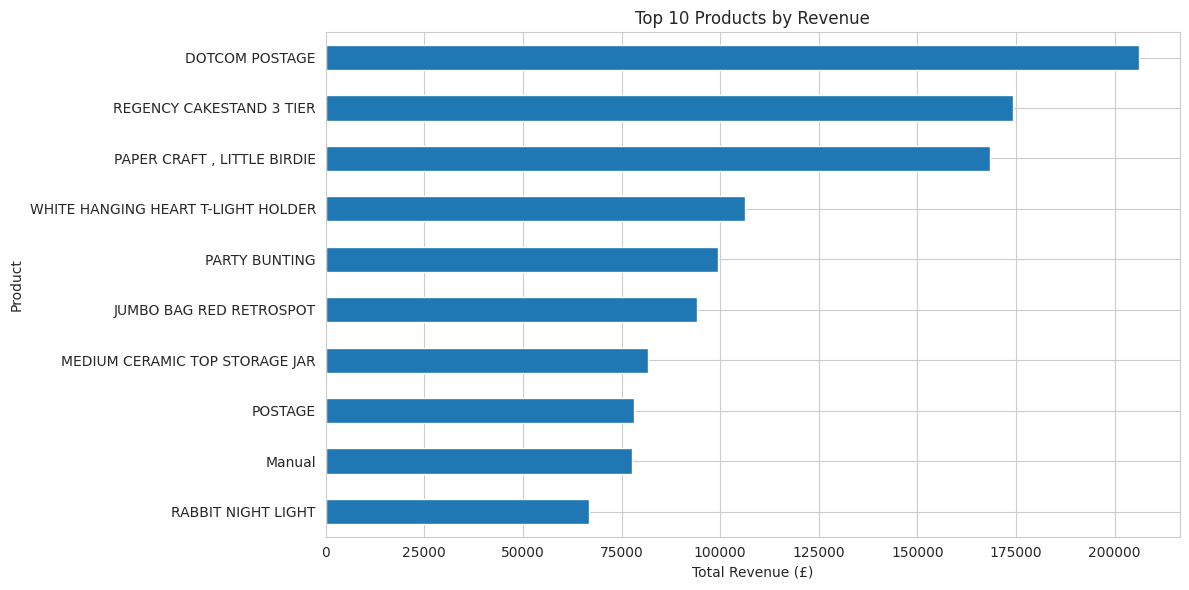

In [46]:
# Visualize top 10 products by revenue

plt.figure(figsize=(12, 6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [47]:
# Top 10 countries by revenue

country_sales = (
    sales_df.groupby('Country')['TotalSales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales

,TotalSales
Country,
United Kingdom,9001744.09
Netherlands,285446.34
EIRE,283140.52
Germany,228678.40
France,209625.37
Australia,138453.81
Spain,61558.56
Switzerland,57067.60
Belgium,41196.34


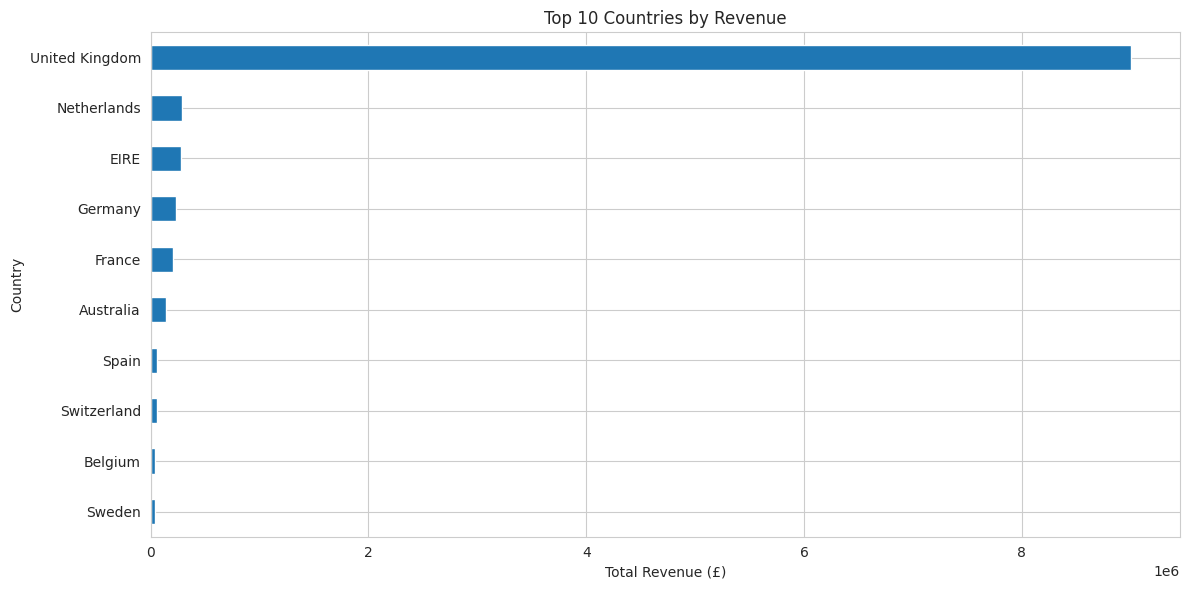

In [48]:
plt.figure(figsize=(12, 6))

country_sales.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [49]:
# Calculate monthly revenue

monthly_sales = (
    sales_df.groupby(
        sales_df['InvoiceDate'].dt.to_period('M')
    )['TotalSales']
    .sum()
)

monthly_sales

,TotalSales
InvoiceDate,
2010-12,821452.73
2011-01,689811.61
2011-02,522545.56
2011-03,716215.26
2011-04,536968.49
2011-05,769296.61
2011-06,760547.01
2011-07,718076.12
2011-08,757841.38


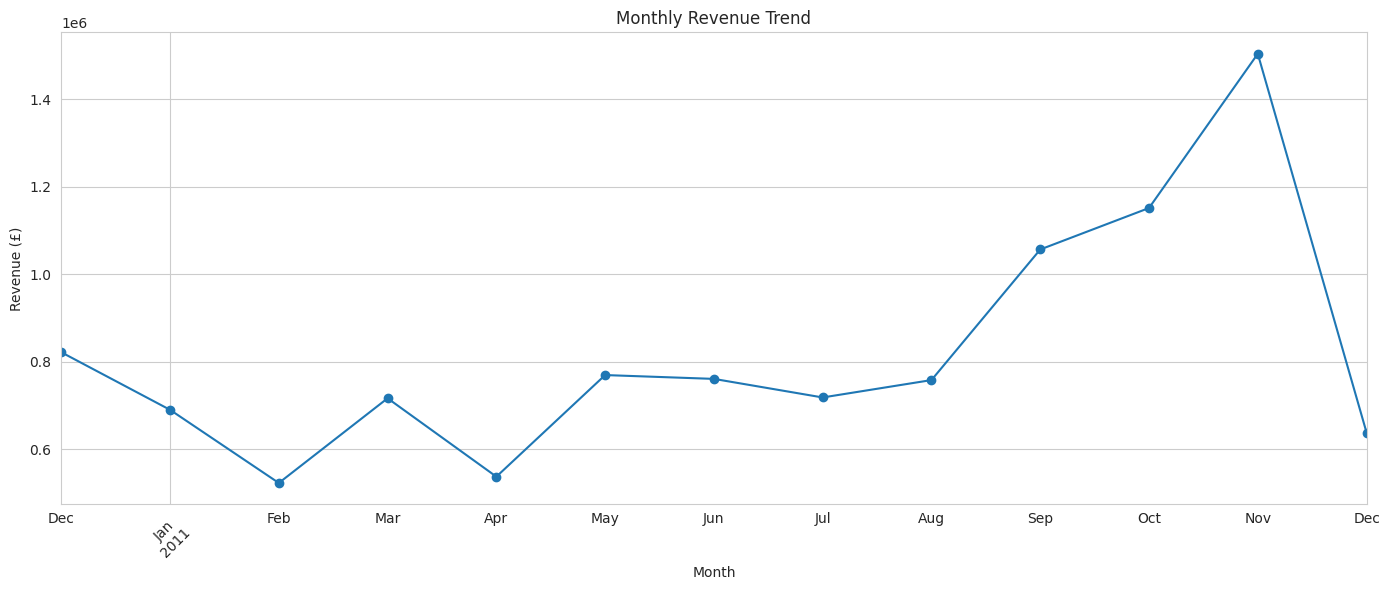

In [50]:
# Monthly revenue trend

plt.figure(figsize=(14, 6))

monthly_sales.plot(marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [51]:
# Monthly transaction count

monthly_transactions = (
    sales_df.groupby(
        sales_df['InvoiceDate'].dt.to_period('M')
    )['InvoiceNo']
    .nunique()
)

monthly_transactions

,InvoiceNo
InvoiceDate,
2010-12,1559
2011-01,1086
2011-02,1100
2011-03,1454
2011-04,1246
2011-05,1681
2011-06,1533
2011-07,1475
2011-08,1361


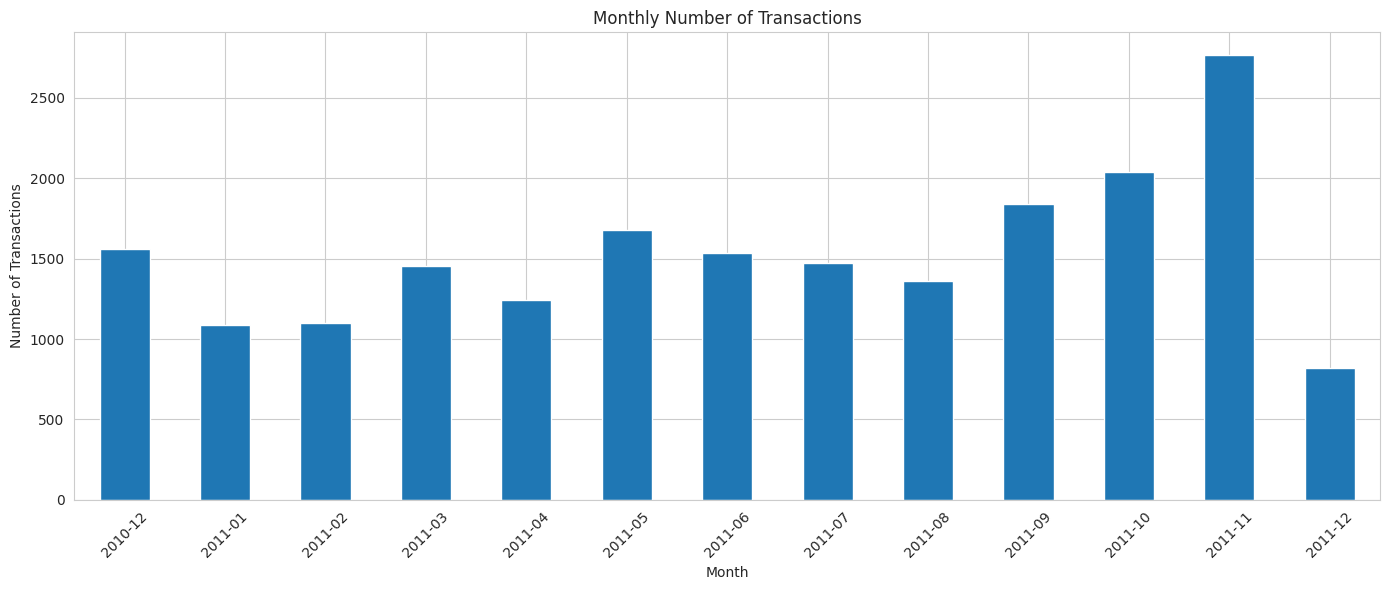

In [52]:
plt.figure(figsize=(14, 6))

monthly_transactions.plot(
    kind='bar'
)

plt.title('Monthly Number of Transactions')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [53]:
# Calculate sales by day of week

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_sales = (
    sales_df.groupby('DayOfWeek')['TotalSales']
    .sum()
    .reindex(day_order)
)

day_sales

,TotalSales
DayOfWeek,
Monday,1775782.07
Tuesday,2175700.51
Wednesday,1847074.38
Thursday,2199292.57
Friday,1837470.49
Saturday,NaN
Sunday,806790.78


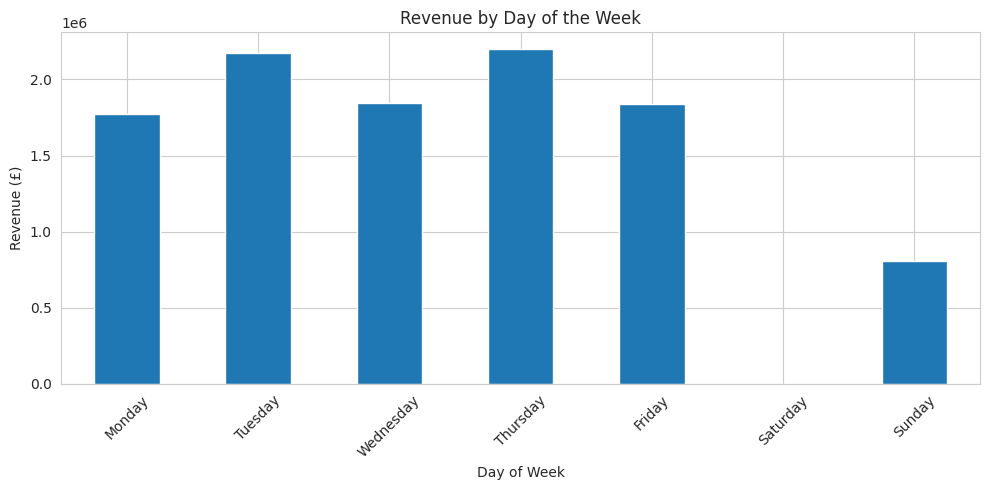

In [54]:
plt.figure(figsize=(10, 5))

day_sales.plot(kind='bar')

plt.title('Revenue by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

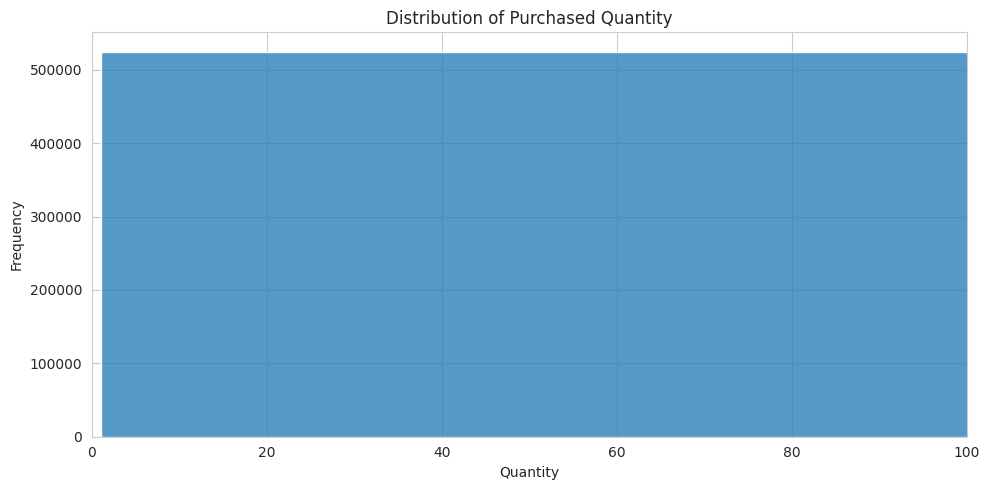

In [55]:
plt.figure(figsize=(10, 5))

sns.histplot(
    sales_df['Quantity'],
    bins=50
)

plt.title('Distribution of Purchased Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.xlim(0, sales_df['Quantity'].quantile(0.99))

plt.tight_layout()
plt.show()

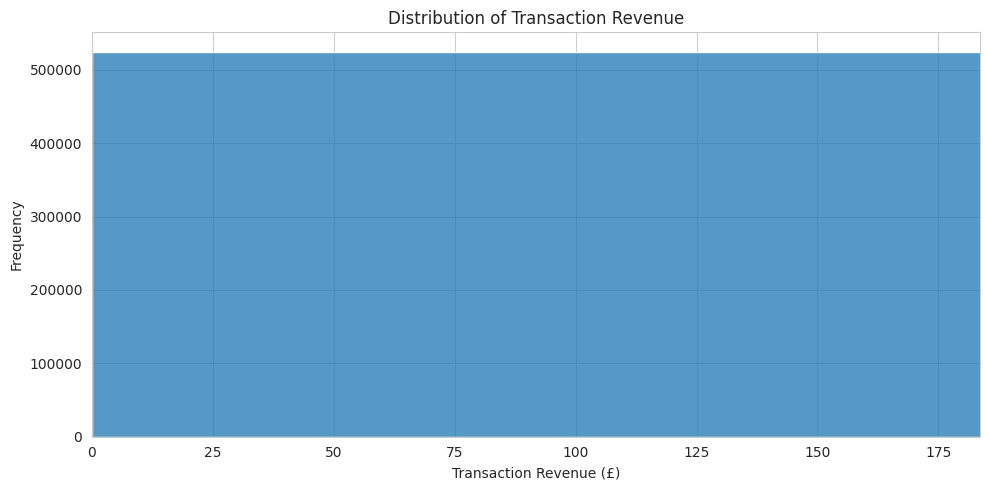

In [56]:
plt.figure(figsize=(10, 5))

sns.histplot(
    sales_df['TotalSales'],
    bins=50
)

plt.title('Distribution of Transaction Revenue')
plt.xlabel('Transaction Revenue (£)')
plt.ylabel('Frequency')

plt.xlim(
    0,
    sales_df['TotalSales'].quantile(0.99)
)

plt.tight_layout()
plt.show()

In [57]:
# Select numerical columns

numeric_columns = [
    'Quantity',
    'UnitPrice',
    'TotalSales'
]

correlation_matrix = sales_df[numeric_columns].corr()

correlation_matrix

,Quantity,UnitPrice,TotalSales
Quantity,1.00,-0.00,0.91
UnitPrice,-0.00,1.00,0.14
TotalSales,0.91,0.14,1.00


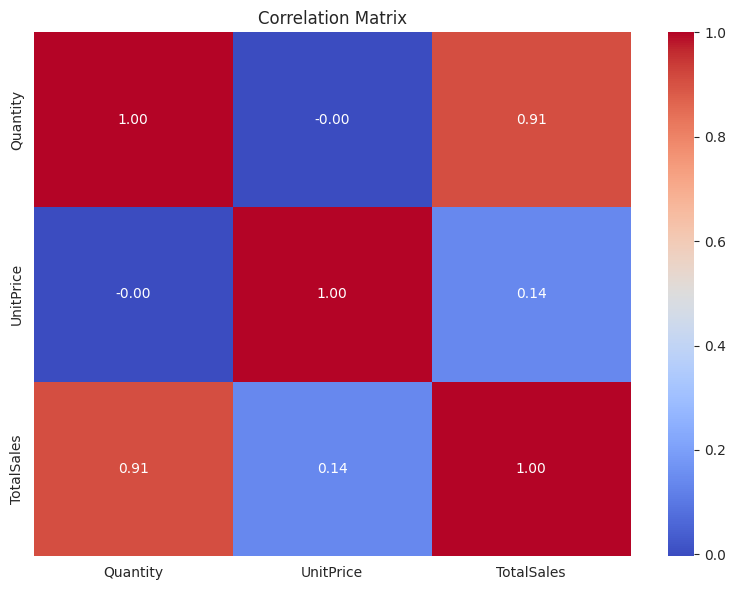

In [58]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [59]:
plt.savefig(
    'monthly_revenue_trend.png',
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

##  Outlier Analysis

Outliers are observations that differ significantly from the majority of the data. The Interquartile Range (IQR) method is used to identify potential outliers in numerical variables such as Quantity, UnitPrice, and TotalSales.

In [60]:
# Function to identify outliers using the IQR method

def find_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return Q1, Q3, lower_bound, upper_bound, outliers

In [61]:
# Identify Quantity outliers

Q1, Q3, lower_bound, upper_bound, quantity_outliers = find_outliers(
    sales_df,
    'Quantity'
)

print("Quantity Q1:", Q1)
print("Quantity Q3:", Q3)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Quantity Outliers:", len(quantity_outliers))

Quantity Q1: 1.0
Quantity Q3: 11.0
Lower Bound: -14.0
Upper Bound: 26.0
Number of Quantity Outliers: 27111


In [62]:
# Identify UnitPrice outliers

Q1, Q3, lower_bound, upper_bound, price_outliers = find_outliers(
    sales_df,
    'UnitPrice'
)

print("UnitPrice Q1:", Q1)
print("UnitPrice Q3:", Q3)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of UnitPrice Outliers:", len(price_outliers))

UnitPrice Q1: 1.25
UnitPrice Q3: 4.13
Lower Bound: -3.0700000000000003
Upper Bound: 8.45
Number of UnitPrice Outliers: 37827


In [63]:
# Identify TotalSales outliers

Q1, Q3, lower_bound, upper_bound, sales_outliers = find_outliers(
    sales_df,
    'TotalSales'
)

print("TotalSales Q1:", Q1)
print("TotalSales Q3:", Q3)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of TotalSales Outliers:", len(sales_outliers))

TotalSales Q1: 3.9
TotalSales Q3: 17.700000000000003
Lower Bound: -16.800000000000004
Upper Bound: 38.400000000000006
Number of TotalSales Outliers: 42624


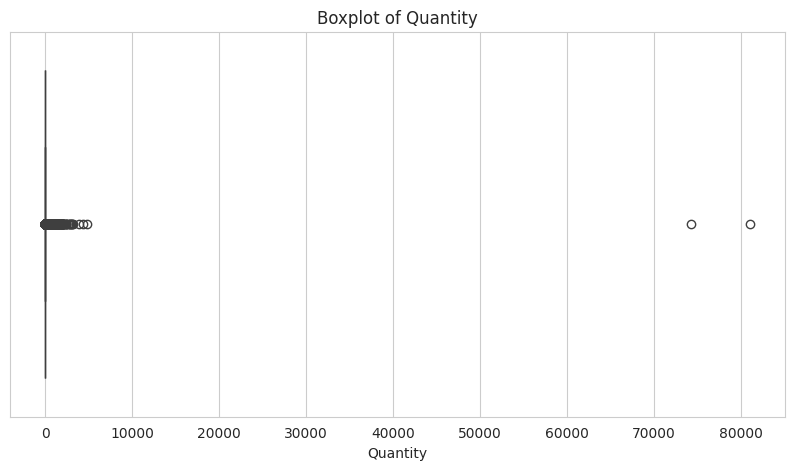

In [64]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=sales_df['Quantity'])

plt.title('Boxplot of Quantity')
plt.xlabel('Quantity')

plt.show()

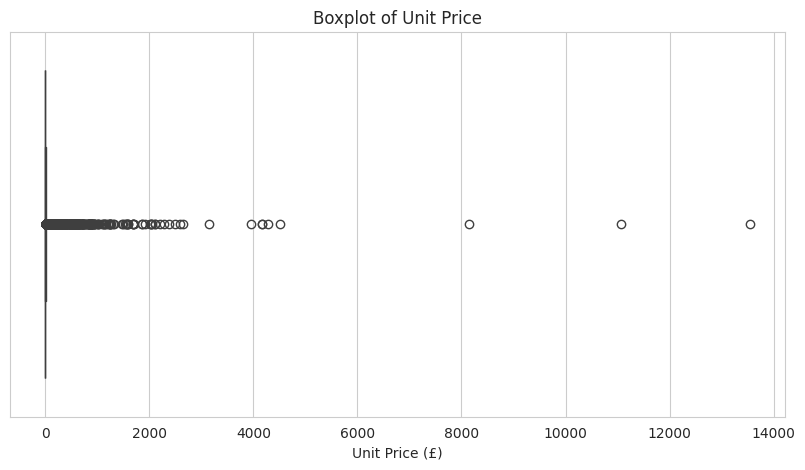

In [65]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=sales_df['UnitPrice'])

plt.title('Boxplot of Unit Price')
plt.xlabel('Unit Price (£)')

plt.show()

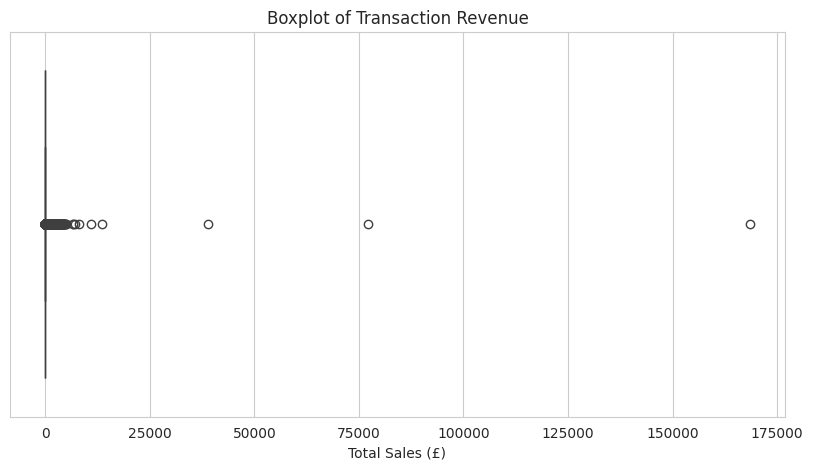

In [66]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=sales_df['TotalSales'])

plt.title('Boxplot of Transaction Revenue')
plt.xlabel('Total Sales (£)')

plt.show()

In [67]:
# Create a copy for outlier-handled analysis

analysis_df = sales_df.copy()

# Calculate IQR boundaries for Quantity
Q1_quantity = analysis_df['Quantity'].quantile(0.25)
Q3_quantity = analysis_df['Quantity'].quantile(0.75)
IQR_quantity = Q3_quantity - Q1_quantity

quantity_upper = Q3_quantity + 1.5 * IQR_quantity

# Calculate IQR boundaries for UnitPrice
Q1_price = analysis_df['UnitPrice'].quantile(0.25)
Q3_price = analysis_df['UnitPrice'].quantile(0.75)
IQR_price = Q3_price - Q1_price

price_upper = Q3_price + 1.5 * IQR_price

# Filter extreme values
analysis_df = analysis_df[
    (analysis_df['Quantity'] <= quantity_upper) &
    (analysis_df['UnitPrice'] <= price_upper)
].copy()

print("Original valid sales records:", len(sales_df))
print("Records after outlier handling:", len(analysis_df))
print("Records removed:", len(sales_df) - len(analysis_df))

Original valid sales records: 524878
Records after outlier handling: 460251
Records removed: 64627


In [68]:
# Compare summary statistics before and after outlier handling

comparison = pd.DataFrame({
    'Before Outlier Handling': sales_df[
        ['Quantity', 'UnitPrice', 'TotalSales']
    ].describe().loc['mean'],

    'After Outlier Handling': analysis_df[
        ['Quantity', 'UnitPrice', 'TotalSales']
    ].describe().loc['mean']
})

comparison

,Before Outlier Handling,After Outlier Handling
Quantity,10.62,6.18
UnitPrice,3.92,2.60
TotalSales,20.28,11.73


In [69]:
print("Before outlier handling:", len(sales_df), "records")
print("After outlier handling:", len(analysis_df), "records")

Before outlier handling: 524878 records
After outlier handling: 460251 records


##  Final Dataset Summary

After cleaning, duplicate removal, validation of numerical values, and outlier handling, the dataset is ready for analysis and visualization.

In [70]:
# Final dataset summary

print("Original dataset:", df.shape)
print("Cleaned sales dataset:", sales_df.shape)
print("Outlier-handled analysis dataset:", analysis_df.shape)

print("\nMissing values in analysis dataset:")
print(analysis_df.isnull().sum())

print("\nDuplicate rows:")
print(analysis_df.duplicated().sum())

Original dataset: (541909, 8)
Cleaned sales dataset: (524878, 14)
Outlier-handled analysis dataset: (460251, 14)

Missing values in analysis dataset:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     115551
Country             0
TotalSales          0
Year                0
Month               0
MonthName           0
Day                 0
DayOfWeek           0
dtype: int64

Duplicate rows:
0


##  Data Visualization

Visualizations are used to identify important trends and patterns in the retail transaction data. The analysis focuses on revenue trends, product performance, geographical distribution, and purchasing behavior.

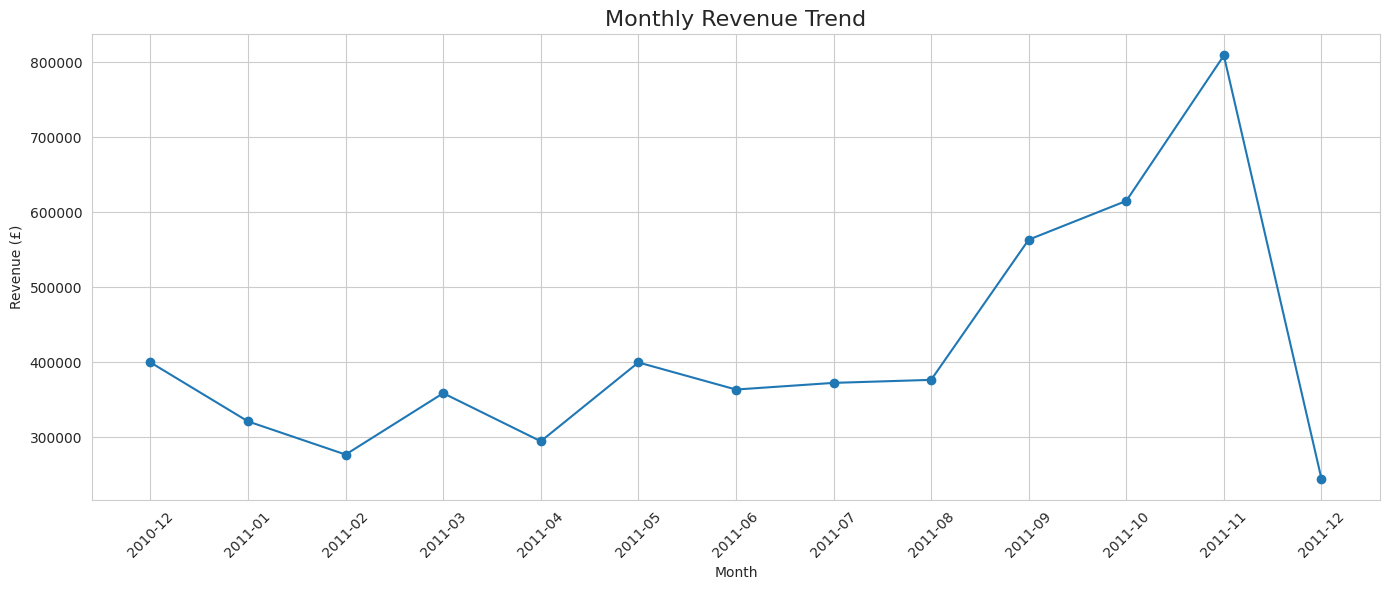

In [71]:
# Monthly revenue trend

monthly_revenue = (
    analysis_df
    .groupby(analysis_df['InvoiceDate'].dt.to_period('M'))['TotalSales']
    .sum()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker='o'
)

plt.title('Monthly Revenue Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

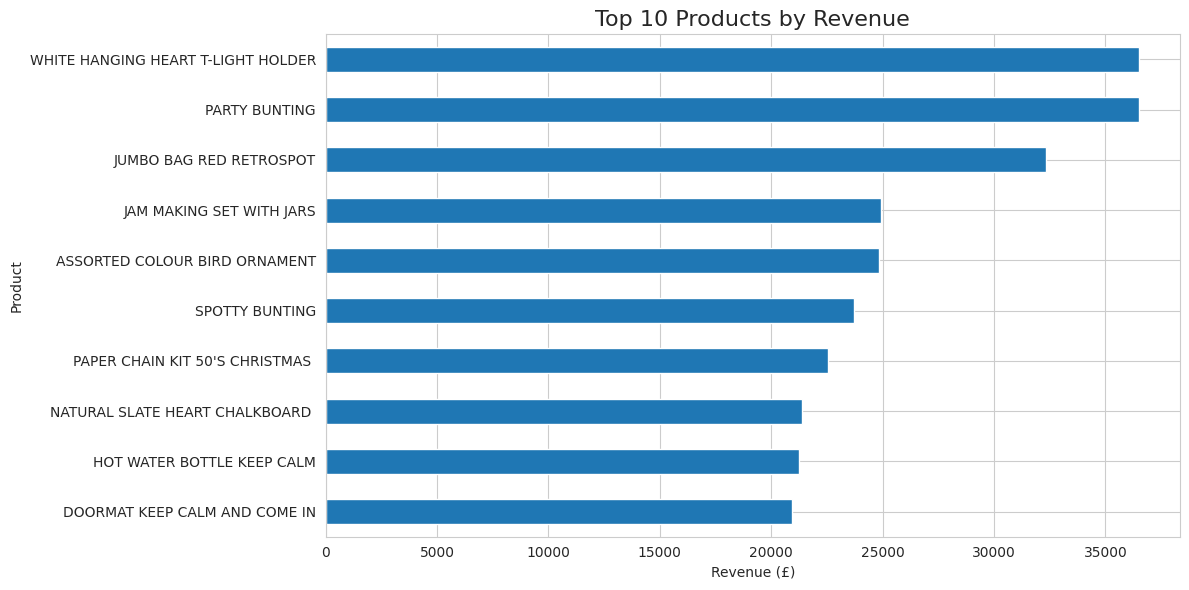

In [72]:
# Top 10 products by revenue

top_10_products = (
    analysis_df
    .groupby('Description')['TotalSales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

top_10_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue', fontsize=16)
plt.xlabel('Revenue (£)')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

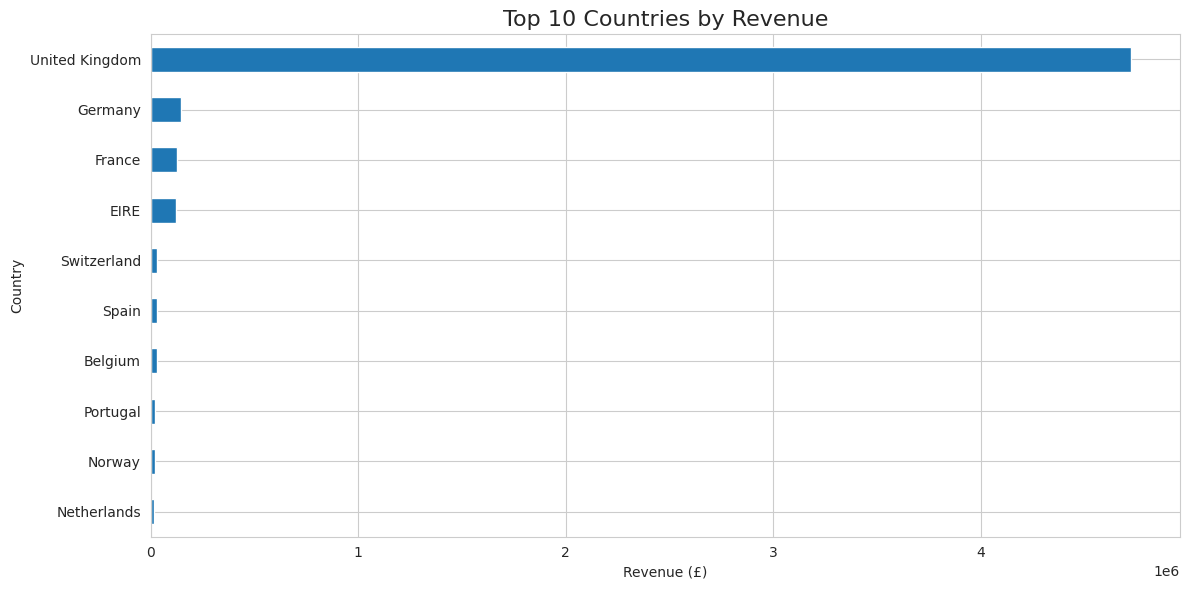

In [73]:
# Top 10 countries by revenue

top_10_countries = (
    analysis_df
    .groupby('Country')['TotalSales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

top_10_countries.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Revenue', fontsize=16)
plt.xlabel('Revenue (£)')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

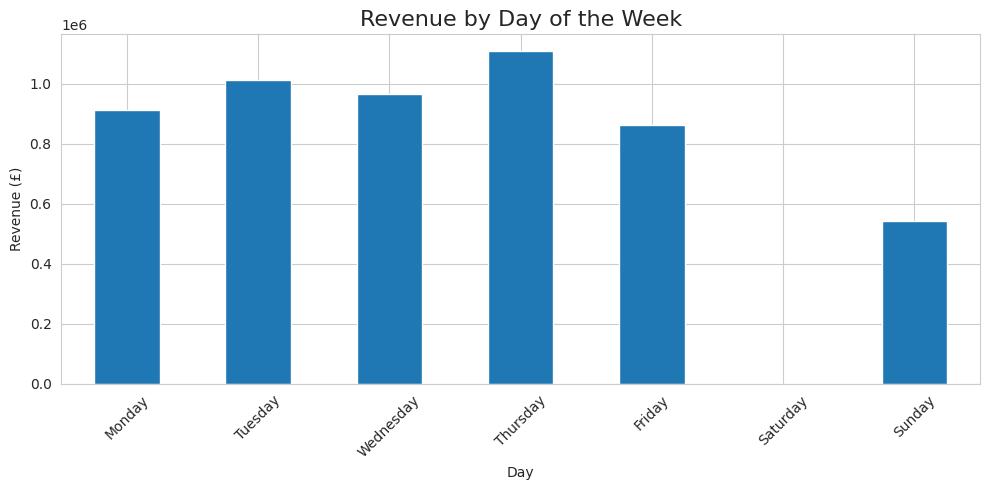

In [74]:
# Revenue by day of the week

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_revenue = (
    analysis_df
    .groupby('DayOfWeek')['TotalSales']
    .sum()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))

day_revenue.plot(kind='bar')

plt.title('Revenue by Day of the Week', fontsize=16)
plt.xlabel('Day')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

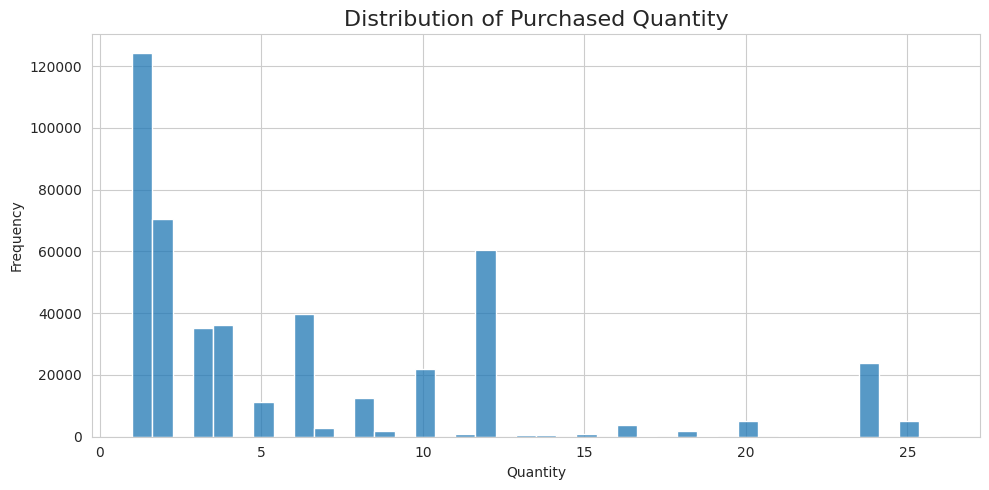

In [75]:
# Distribution of purchased quantity

plt.figure(figsize=(10, 5))

sns.histplot(
    analysis_df['Quantity'],
    bins=40
)

plt.title('Distribution of Purchased Quantity', fontsize=16)
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

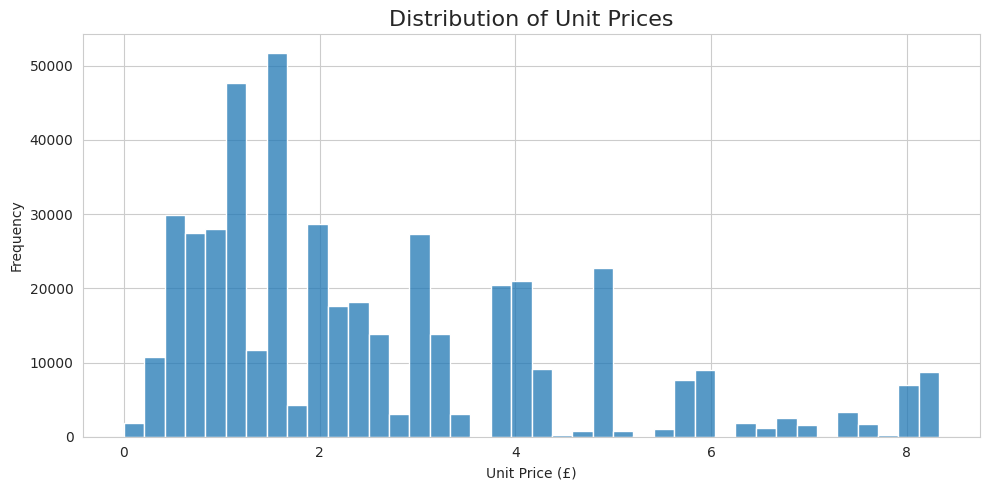

In [76]:
# Distribution of unit prices

plt.figure(figsize=(10, 5))

sns.histplot(
    analysis_df['UnitPrice'],
    bins=40
)

plt.title('Distribution of Unit Prices', fontsize=16)
plt.xlabel('Unit Price (£)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

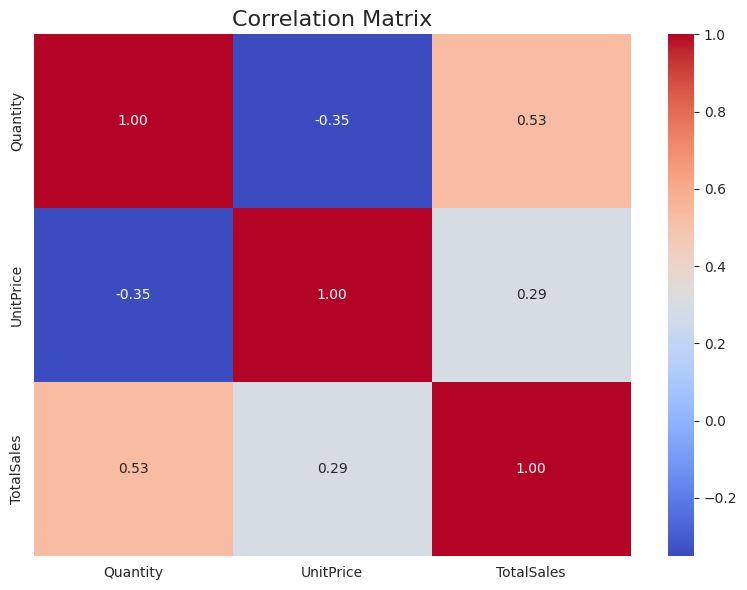

In [77]:
# Correlation between numerical variables

numeric_columns = [
    'Quantity',
    'UnitPrice',
    'TotalSales'
]

correlation_matrix = analysis_df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix', fontsize=16)

plt.tight_layout()
plt.show()

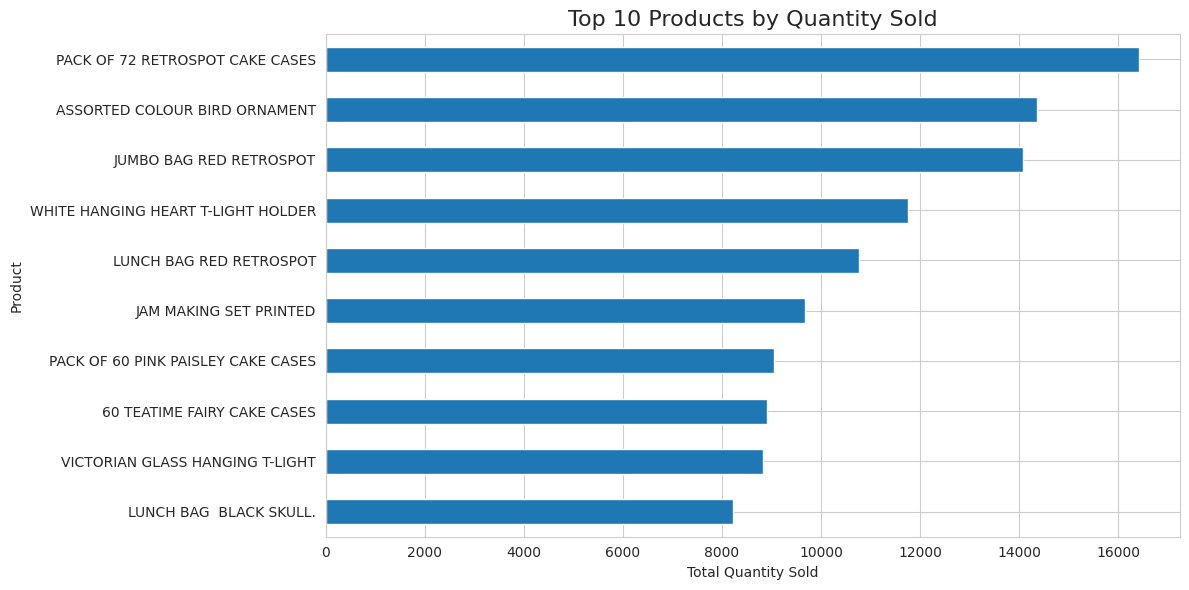

In [78]:
# Top 10 products by quantity sold

top_quantity_products = (
    analysis_df
    .groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

top_quantity_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Quantity Sold', fontsize=16)
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [79]:
# Create folder for visualizations

import os

os.makedirs('visualizations', exist_ok=True)

print("Visualization folder created successfully.")

Visualization folder created successfully.


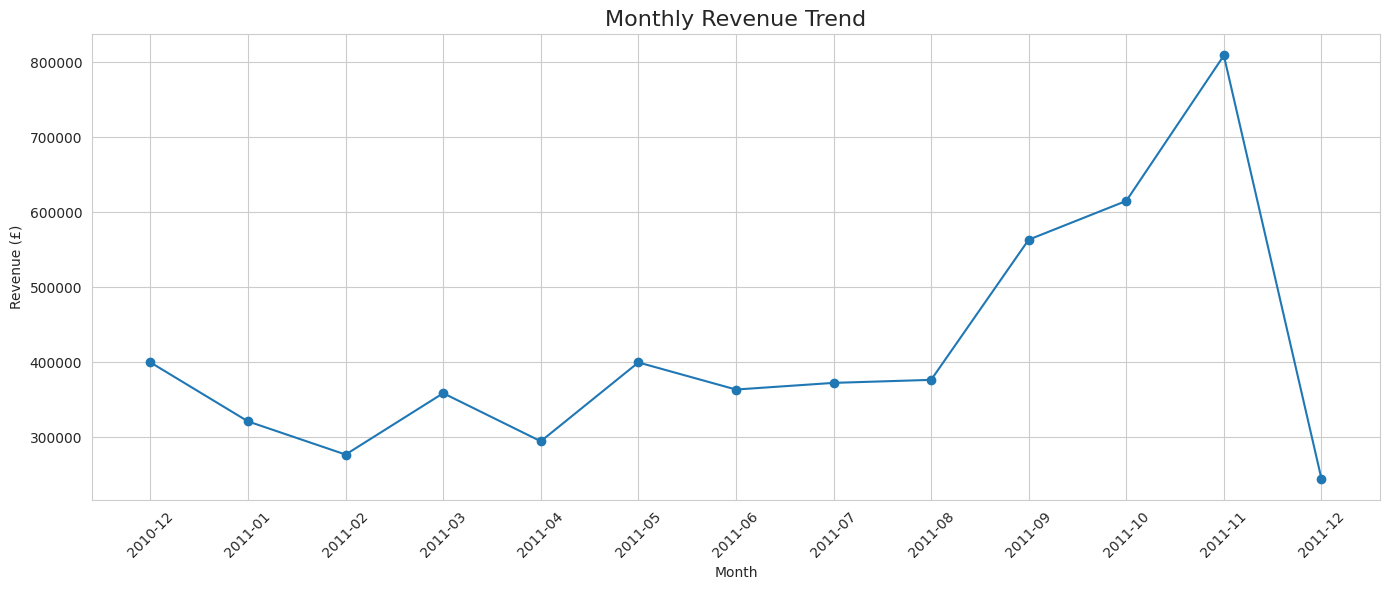

In [80]:
# Save monthly revenue visualization

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker='o'
)

plt.title('Monthly Revenue Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()

plt.savefig(
    'visualizations/monthly_revenue_trend.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

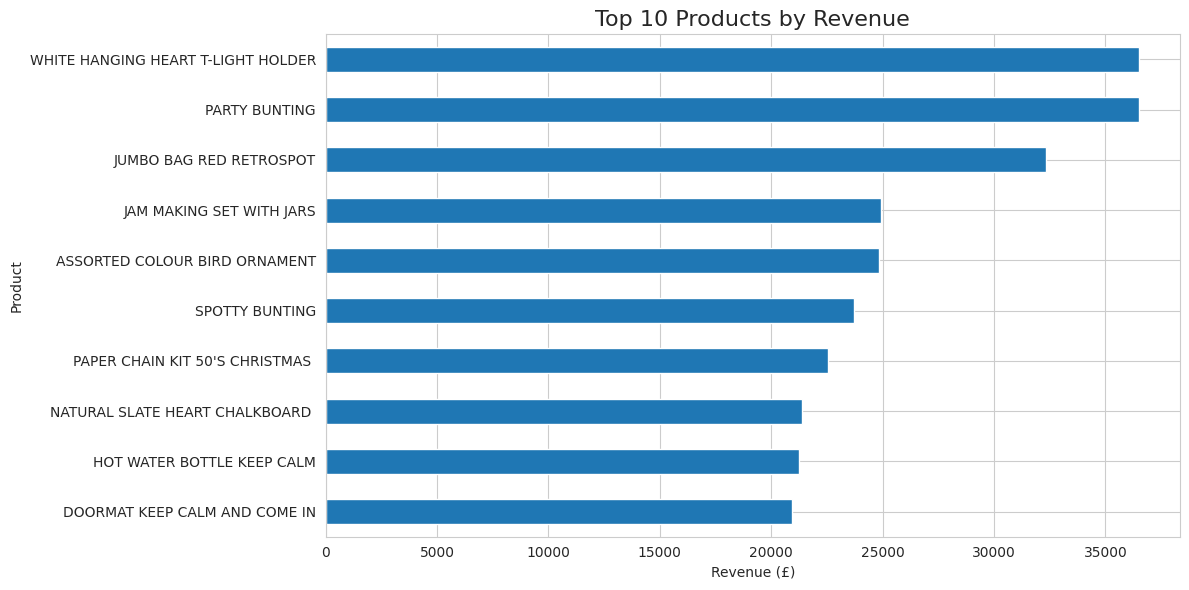

In [81]:
plt.figure(figsize=(12, 6))

top_10_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue', fontsize=16)
plt.xlabel('Revenue (£)')
plt.ylabel('Product')

plt.tight_layout()

plt.savefig(
    'visualizations/top_10_products.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

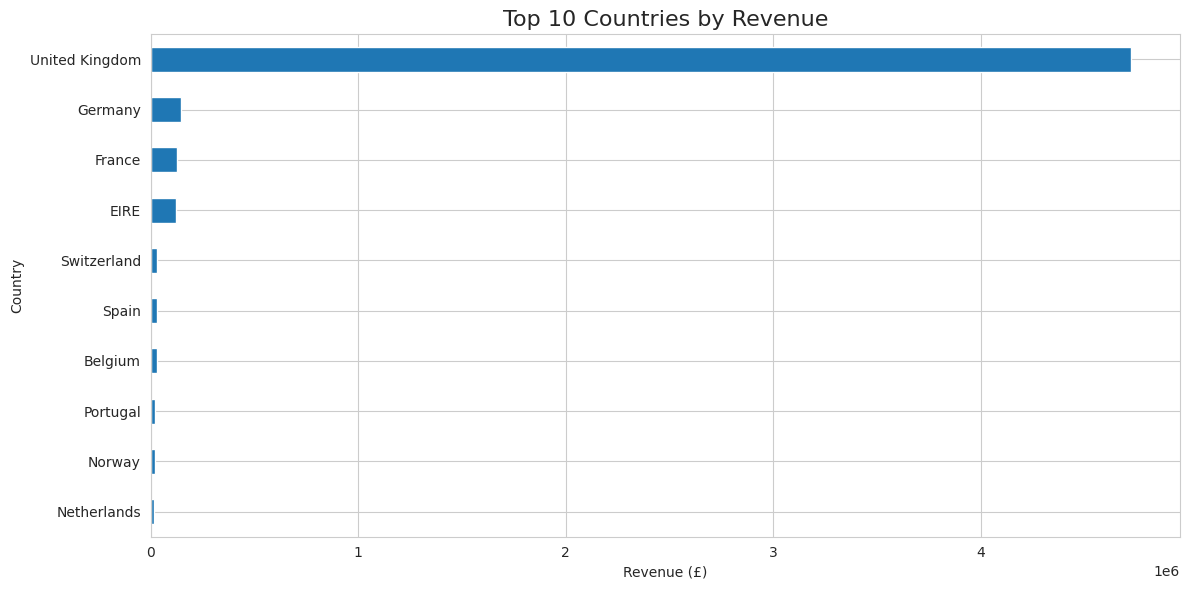

In [82]:
plt.figure(figsize=(12, 6))

top_10_countries.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Revenue', fontsize=16)
plt.xlabel('Revenue (£)')
plt.ylabel('Country')

plt.tight_layout()

plt.savefig(
    'visualizations/top_10_countries.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

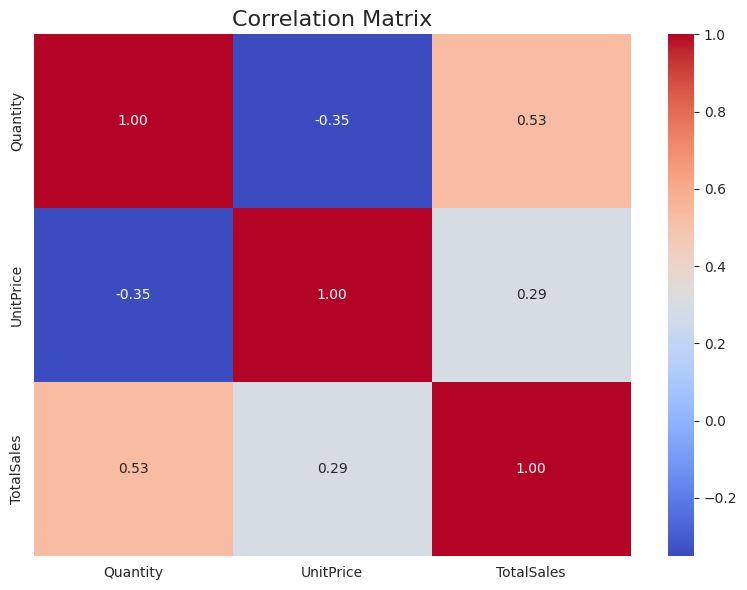

In [83]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix', fontsize=16)

plt.tight_layout()

plt.savefig(
    'visualizations/correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

##  Key Insights

The analysis of the Online Retail dataset provides several important observations:

1. Revenue varies considerably across different months, indicating changes in purchasing activity over time.

2. A relatively small group of products contributes a significant portion of the overall revenue.

3. The United Kingdom represents the largest share of revenue among the countries in the dataset.

4. Purchasing activity varies across days of the week, indicating differences in customer purchasing behavior.

5. The distribution of Quantity and UnitPrice contains extreme observations, which were investigated using the IQR method.

6. The correlation analysis helps identify relationships between Quantity, UnitPrice, and TotalSales.

7. Data cleaning significantly improves the reliability of the analysis by removing duplicate records, handling missing descriptions, filtering invalid transactions, and addressing extreme values.

##  Conclusion

This project demonstrated a complete data cleaning and visualization workflow using the Online Retail dataset.

The dataset was inspected for missing values, duplicate records, invalid transactions, and potential outliers. Missing product descriptions were removed, duplicate records were eliminated, and invalid quantity and price values were excluded from the sales analysis. Potential outliers were identified using the IQR method and a separate analysis dataset was created for robust visualization.

Several visualizations were developed to understand monthly revenue trends, product performance, geographical revenue distribution, purchasing behavior, and relationships between numerical variables.

Overall, the project demonstrates how raw transactional data can be transformed into a cleaner and more useful dataset and then used to generate meaningful insights through exploratory analysis and visualization.